In [1]:
# =========================================================
# Day 5. 시계열 핵심 실습
# 파일: labeled_data.csv
# 목표: TimeStamp 기반 흐름 확인 + 간단 예측
# =========================================================

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from sklearn.impute import SimpleImputer # 결측치 처리용
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [5]:
plt.rcParams["figure.figsize"] = (10, 4)
pd.set_option("display.max_columns", None)

In [6]:
# ---------------------------------------------------------
# 1. 데이터 불러오기
# ---------------------------------------------------------
df = pd.read_csv("labeled_data.csv")
df

,_id,TimeStamp,PART_FACT_PLAN_DATE,PART_FACT_SERIAL,PART_NAME,EQUIP_CD,EQUIP_NAME,PassOrFail,Reason,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Switch_Over_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,Max_Screw_RPM,Average_Screw_RPM,Max_Injection_Pressure,Max_Switch_Over_Pressure,Max_Back_Pressure,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Barrel_Temperature_7,Hopper_Temperature,Mold_Temperature_1,Mold_Temperature_2,Mold_Temperature_3,Mold_Temperature_4,Mold_Temperature_5,Mold_Temperature_6,Mold_Temperature_7,Mold_Temperature_8,Mold_Temperature_9,Mold_Temperature_10,Mold_Temperature_11,Mold_Temperature_12
0,5f8928bb9c0189cc666ef19b,2020-10-16 04:57:47,2020-10-16 오전 12:00:00,24,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,Y,NaN,9.59,4.47,16.920000,59.520000,7.13,653.409973,0.0,68.849998,647.98999,55.400002,30.700001,292.500000,141.800003,136.800003,37.400002,59.299999,276.500000,274.700012,274.799988,269.200012,255.000000,229.699997,0.0,66.300003,0.0,0.0,24.799999,27.500000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,5f8928de9c0189cc666ef20b,2020-10-16 04:58:48,2020-10-16 오전 12:00:00,24,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,Y,NaN,9.60,4.48,16.910000,59.580002,7.13,653.409973,0.0,68.839996,647.98999,55.299999,30.799999,292.500000,141.800003,136.899994,37.500000,59.299999,276.200012,275.500000,275.299988,270.799988,254.699997,229.500000,0.0,67.199997,0.0,0.0,24.799999,27.600000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,5f8928df9c0189cc666ef213,2020-10-16 04:58:48,2020-10-16 오전 12:00:00,23,CN7 W/S SIDE MLD'G LH,S14,650톤-우진2호기,Y,NaN,9.60,4.48,16.910000,59.580002,7.13,653.409973,0.0,68.839996,647.98999,55.299999,30.799999,292.500000,141.800003,136.899994,37.500000,59.299999,276.200012,275.500000,275.299988,270.799988,254.699997,229.500000,0.0,67.199997,0.0,0.0,24.799999,27.600000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,5f8928f39c0189cc666ef25e,2020-10-16 04:59:48,2020-10-16 오전 12:00:00,23,CN7 W/S SIDE MLD'G LH,S14,650톤-우진2호기,Y,NaN,9.59,4.48,16.910000,59.560001,7.13,653.419983,0.0,68.839996,647.98999,55.299999,31.000000,292.500000,141.800003,136.800003,37.500000,59.299999,276.500000,275.000000,275.399994,271.100006,254.899994,230.000000,0.0,66.900002,0.0,0.0,25.000000,27.600000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5f8928f59c0189cc666ef265,2020-10-16 04:59:48,2020-10-16 오전 12:00:00,24,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,Y,NaN,9.59,4.48,16.910000,59.560001,7.13,653.419983,0.0,68.839996,647.98999,55.299999,31.000000,292.500000,141.800003,136.800003,37.500000,59.299999,276.500000,275.000000,275.399994,271.100006,254.899994,230.000000,0.0,66.900002,0.0,0.0,25.000000,27.600000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7991,5fa112859c0189cc66dabe34,2020-11-03 08:17:36,2020-11-03 오전 12:00:00,6,CN7 W/S SIDE MLD'G LH,S14,650톤-우진2호기,Y,NaN,9.60,4.48,16.620001,59.560001,7.11,653.429993,0.0,68.330002,647.98999,54.900002,30.700001,29.200001,142.100006,137.000000,38.299999,59.900002,276.500000,274.899994,275.100006,269.500000,255.600006,229.600006,0.0,66.099998,0.0,0.0,21.000000,22.400000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7992,5fa112869c0189cc66dabe42,2020-11-03 08:18:37,2020-11-03 오전 12:00:00,7,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,Y,NaN,9.60,4.48,16.650000,59.560001,7.11,653.429993,0.0,68.349998,647.98999,55.000000,30.700001,29.200001,142.100006,136.800003,38.400002,59.900002,275.799988,275.299988,275.500000,270.700012,254.899994,230.000000,0.0,66.099998,0.0,0.0,21.000000,22.400000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7993,5fa112879c0189cc66dabe50,2020-11-03 08:18:37,2020-11-03 오전 12:00:00,6,CN7 W/S SIDE MLD'G LH,S14,650톤-우진2호기,Y,NaN,9.60,4.48,16.650000,59.560001,7.11,653.429993,0.0,68.349998,647.98999,55.000000,30.700001,29.200001,142.100006,1

In [7]:
# 필요한 컬럼만 사용
df["TimeStamp"] = pd.to_datetime(df["TimeStamp"], errors="coerce")
df = df.dropna(subset=["TimeStamp"]).sort_values("TimeStamp").reset_index(drop=True)
df

,_id,TimeStamp,PART_FACT_PLAN_DATE,PART_FACT_SERIAL,PART_NAME,EQUIP_CD,EQUIP_NAME,PassOrFail,Reason,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Switch_Over_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,Max_Screw_RPM,Average_Screw_RPM,Max_Injection_Pressure,Max_Switch_Over_Pressure,Max_Back_Pressure,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Barrel_Temperature_7,Hopper_Temperature,Mold_Temperature_1,Mold_Temperature_2,Mold_Temperature_3,Mold_Temperature_4,Mold_Temperature_5,Mold_Temperature_6,Mold_Temperature_7,Mold_Temperature_8,Mold_Temperature_9,Mold_Temperature_10,Mold_Temperature_11,Mold_Temperature_12
0,5f8928bb9c0189cc666ef19b,2020-10-16 04:57:47,2020-10-16 오전 12:00:00,24,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,Y,NaN,9.59,4.47,16.92,59.520000,7.13,653.409973,0.0,68.849998,647.98999,55.400002,30.700001,292.5,141.800003,136.800003,37.400002,59.299999,276.500000,274.700012,274.799988,269.200012,255.000000,229.699997,0.0,66.300003,0.0,0.0,24.799999,27.500000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,5f8928de9c0189cc666ef20b,2020-10-16 04:58:48,2020-10-16 오전 12:00:00,24,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,Y,NaN,9.60,4.48,16.91,59.580002,7.13,653.409973,0.0,68.839996,647.98999,55.299999,30.799999,292.5,141.800003,136.899994,37.500000,59.299999,276.200012,275.500000,275.299988,270.799988,254.699997,229.500000,0.0,67.199997,0.0,0.0,24.799999,27.600000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,5f8928df9c0189cc666ef213,2020-10-16 04:58:48,2020-10-16 오전 12:00:00,23,CN7 W/S SIDE MLD'G LH,S14,650톤-우진2호기,Y,NaN,9.60,4.48,16.91,59.580002,7.13,653.409973,0.0,68.839996,647.98999,55.299999,30.799999,292.5,141.800003,136.899994,37.500000,59.299999,276.200012,275.500000,275.299988,270.799988,254.699997,229.500000,0.0,67.199997,0.0,0.0,24.799999,27.600000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,5f8928f39c0189cc666ef25e,2020-10-16 04:59:48,2020-10-16 오전 12:00:00,23,CN7 W/S SIDE MLD'G LH,S14,650톤-우진2호기,Y,NaN,9.59,4.48,16.91,59.560001,7.13,653.419983,0.0,68.839996,647.98999,55.299999,31.000000,292.5,141.800003,136.800003,37.500000,59.299999,276.500000,275.000000,275.399994,271.100006,254.899994,230.000000,0.0,66.900002,0.0,0.0,25.000000,27.600000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5f8928f59c0189cc666ef265,2020-10-16 04:59:48,2020-10-16 오전 12:00:00,24,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,Y,NaN,9.59,4.48,16.91,59.560001,7.13,653.419983,0.0,68.839996,647.98999,55.299999,31.000000,292.5,141.800003,136.800003,37.500000,59.299999,276.500000,275.000000,275.399994,271.100006,254.899994,230.000000,0.0,66.900002,0.0,0.0,25.000000,27.600000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7991,5fa23fbc9c0189cc66e44ddf,2020-11-04 05:43:29,2020-11-04 오전 12:00:00,10,"RG3 MOLD'G W/SHLD, RH",S14,650톤-우진2호기,Y,NaN,1.07,0.94,13.12,61.779999,6.79,654.250000,0.0,53.610001,4.63000,127.500000,31.100000,29.0,143.000000,118.300003,57.099998,61.500000,285.899994,284.899994,285.700012,274.899994,265.000000,234.899994,0.0,64.500000,0.0,0.0,22.500000,24.299999,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7992,5fa23fbd9c0189cc66e44de3,2020-11-04 05:43:29,2020-11-04 오전 12:00:00,9,"RG3 MOLD'G W/SHLD, LH",S14,650톤-우진2호기,Y,NaN,1.07,0.94,13.12,61.779999,6.79,654.250000,0.0,53.610001,4.63000,127.500000,31.100000,29.0,143.000000,118.300003,57.099998,61.500000,285.899994,284.899994,285.700012,274.899994,265.000000,234.899994,0.0,64.500000,0.0,0.0,22.500000,24.299999,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7993,5fa36b009c0189cc66eebed7,2020-11-05 03:00:02,2020-11-05 오전 12:00:00,4,"RG3 MOLD'G W/SHLD, RH",S14,650톤-우진2호기,Y,NaN,1.07,0.94,12.96,61.779999,6.79,654.270020,0.0,53.669998,4.63000,128.000000,30.900000,29.0,142.899994,117.199997,56.200001,60.599998,285.899994,284.899994,285.500000,274.3

In [8]:
# 불량 라벨 숫자로 변환 (Y=정상, N=불량 가정)
df["PassOrFail_binary"] = df["PassOrFail"].map({"Y": 0, "N": 1})
df.head(1)

,_id,TimeStamp,PART_FACT_PLAN_DATE,PART_FACT_SERIAL,PART_NAME,EQUIP_CD,EQUIP_NAME,PassOrFail,Reason,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Switch_Over_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,Max_Screw_RPM,Average_Screw_RPM,Max_Injection_Pressure,Max_Switch_Over_Pressure,Max_Back_Pressure,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Barrel_Temperature_7,Hopper_Temperature,Mold_Temperature_1,Mold_Temperature_2,Mold_Temperature_3,Mold_Temperature_4,Mold_Temperature_5,Mold_Temperature_6,Mold_Temperature_7,Mold_Temperature_8,Mold_Temperature_9,Mold_Temperature_10,Mold_Temperature_11,Mold_Temperature_12,PassOrFail_binary
0,5f8928bb9c0189cc666ef19b,2020-10-16 04:57:47,2020-10-16 오전 12:00:00,24,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,Y,NaN,9.59,4.47,16.92,59.52,7.13,653.409973,0.0,68.849998,647.98999,55.400002,30.700001,292.5,141.800003,136.800003,37.400002,59.299999,276.5,274.700012,274.799988,269.200012,255.0,229.699997,0.0,66.300003,0.0,0.0,24.799999,27.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [9]:
# 예측할 타깃
target_col = "Cycle_Time"

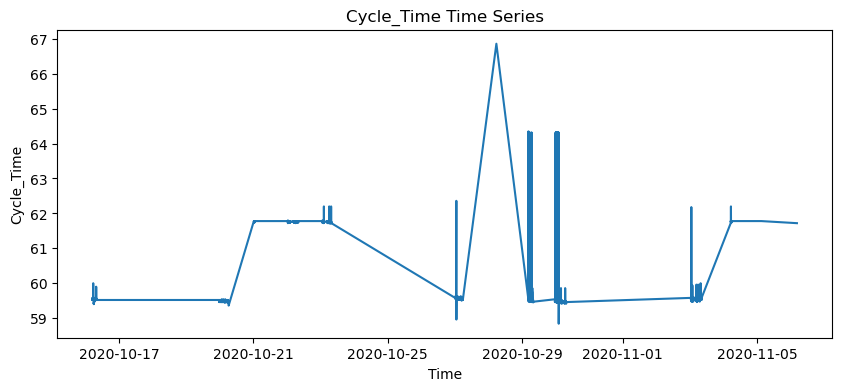

In [10]:
# ---------------------------------------------------------
# 2. 시계열 흐름 보기
# ---------------------------------------------------------
plt.plot(df["TimeStamp"], df[target_col])
plt.title("Cycle_Time Time Series")
plt.xlabel("Time")
plt.ylabel("Cycle_Time")
plt.show()

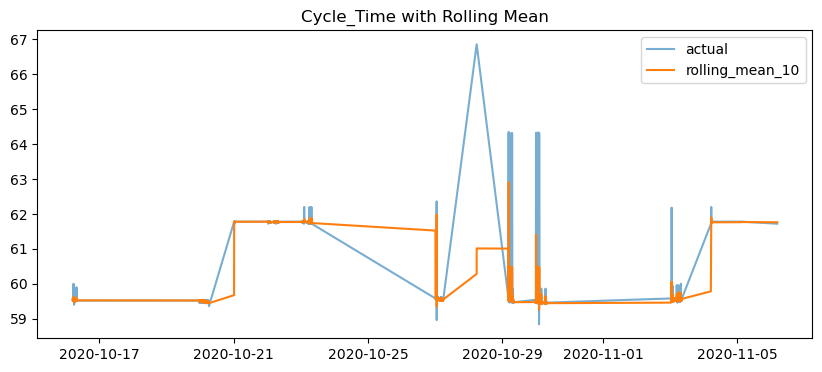

In [11]:
# ---------------------------------------------------------
# 3. rolling mean / rolling std
# ---------------------------------------------------------
df["rolling_mean_10"] = df[target_col].rolling(10).mean()
df["rolling_std_10"] = df[target_col].rolling(10).std()

plt.plot(df["TimeStamp"], df[target_col], label="actual", alpha=0.6)
plt.plot(df["TimeStamp"], df["rolling_mean_10"], label="rolling_mean_10")
plt.title("Cycle_Time with Rolling Mean")
plt.legend()
plt.show()

In [12]:
# ---------------------------------------------------------
# 4. lag / rolling feature 만들기
# ---------------------------------------------------------
df["lag_1"] = df[target_col].shift(1)
df["lag_3"] = df[target_col].shift(3)
df["lag_5"] = df[target_col].shift(5)

df["rolling_mean_3"] = df[target_col].shift(1).rolling(3).mean()
df["rolling_mean_5"] = df[target_col].shift(1).rolling(5).mean()

df["hour"] = df["TimeStamp"].dt.hour
df["dayofweek"] = df["TimeStamp"].dt.dayofweek

feature_cols = [
    "Injection_Time",
    "Filling_Time",
    "Max_Injection_Pressure",
    "lag_1",
    "lag_3",
    "lag_5",
    "rolling_mean_3",
    "rolling_mean_5",
    "hour",
    "dayofweek"
]

In [13]:
# ---------------------------------------------------------
# 5. 시간순 train / test split
# ---------------------------------------------------------
split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

# 결측 보정
imputer = SimpleImputer(strategy="mean")
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=feature_cols, index=X_train.index)
X_test = pd.DataFrame(imputer.transform(X_test), columns=feature_cols, index=X_test.index)

In [14]:
# ---------------------------------------------------------
# 6. Baseline 예측
# ---------------------------------------------------------
baseline_pred = test_df[target_col].shift(1) # 직전 값을 채운다. 뜻:어제랑 똑같을 거야
baseline_pred.iloc[0] = train_df[target_col].iloc[-1] # 비어있는 첫 칸을 메워줌

In [15]:
# ---------------------------------------------------------
# 7. Linear Regression
# ---------------------------------------------------------
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)

In [16]:
# ---------------------------------------------------------
# 8. Random Forest
# ---------------------------------------------------------
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

In [17]:
# ---------------------------------------------------------
# 9. 평가 함수
# ---------------------------------------------------------
def print_metrics(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)

    print(f"\n=== {name} ===")
    print("MAE :", round(mae, 4))
    print("RMSE:", round(rmse, 4))
    print("R²  :", round(r2, 4))

In [18]:
print_metrics(y_test, baseline_pred, "Baseline")
print_metrics(y_test, linear_pred, "Linear Regression")
print_metrics(y_test, rf_pred, "Random Forest")


=== Baseline ===
MAE : 0.0069
RMSE: 0.062
R²  : 0.983

=== Linear Regression ===
MAE : 0.0328
RMSE: 0.0496
R²  : 0.9891

=== Random Forest ===
MAE : 0.0103
RMSE: 0.0391
R²  : 0.9932


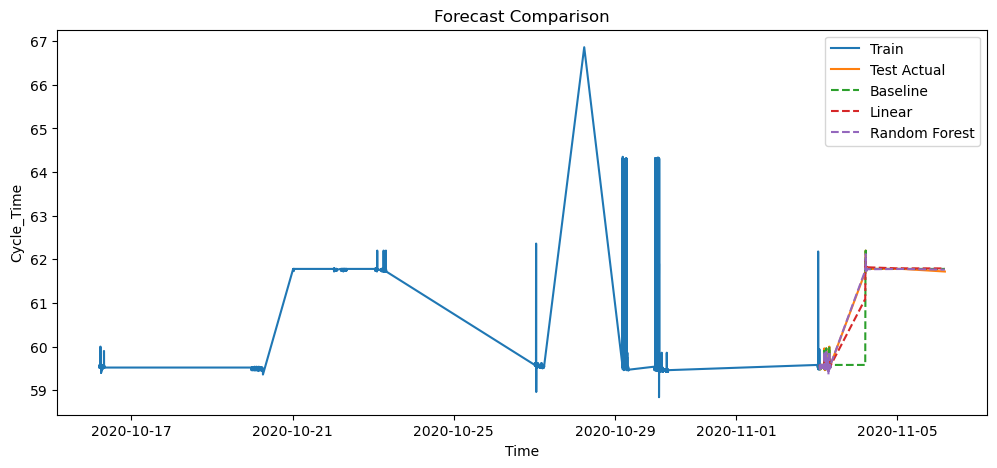

In [19]:
# ---------------------------------------------------------
# 10. 예측 결과 비교
# ---------------------------------------------------------
plt.figure(figsize=(12, 5))
plt.plot(train_df["TimeStamp"], train_df[target_col], label="Train")
plt.plot(test_df["TimeStamp"], y_test.values, label="Test Actual")
plt.plot(test_df["TimeStamp"], baseline_pred.values, label="Baseline", linestyle="--")
plt.plot(test_df["TimeStamp"], linear_pred, label="Linear", linestyle="--")
plt.plot(test_df["TimeStamp"], rf_pred, label="Random Forest", linestyle="--")
plt.title("Forecast Comparison")
plt.xlabel("Time")
plt.ylabel("Cycle_Time")
plt.legend()
plt.show()

In [20]:
# ---------------------------------------------------------
# 11. 중요 변수 확인
# ---------------------------------------------------------
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\n=== 중요 변수 ===")
display(importance_df)


=== 중요 변수 ===


,feature,importance
1,Filling_Time,0.842695
2,Max_Injection_Pressure,0.107817
0,Injection_Time,0.044943
3,lag_1,0.002760
9,dayofweek,0.000577
7,rolling_mean_5,0.000462
5,lag_5,0.000264
4,lag_3,0.000168
6,rolling_mean_3,0.000165
8,hour,0.000149


In [21]:
fail_df = test_df[test_df["PassOrFail_binary"] == 1]
fail_df

,_id,TimeStamp,PART_FACT_PLAN_DATE,PART_FACT_SERIAL,PART_NAME,EQUIP_CD,EQUIP_NAME,PassOrFail,Reason,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Switch_Over_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,Max_Screw_RPM,Average_Screw_RPM,Max_Injection_Pressure,Max_Switch_Over_Pressure,Max_Back_Pressure,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Barrel_Temperature_7,Hopper_Temperature,Mold_Temperature_1,Mold_Temperature_2,Mold_Temperature_3,Mold_Temperature_4,Mold_Temperature_5,Mold_Temperature_6,Mold_Temperature_7,Mold_Temperature_8,Mold_Temperature_9,Mold_Temperature_10,Mold_Temperature_11,Mold_Temperature_12,PassOrFail_binary,rolling_mean_10,rolling_std_10,lag_1,lag_3,lag_5,rolling_mean_3,rolling_mean_5,hour,dayofweek
7058,5fa0e06e9c0189cc66d7161d,2020-11-03 04:44:17,2020-11-03 오전 12:00:00,6,CN7 W/S SIDE MLD'G LH,S14,650톤-우진2호기,N,미성형,9.60,4.48,16.58,59.520000,7.11,653.429993,0.0,68.360001,647.98999,55.000000,30.600000,29.200001,142.100006,136.800003,38.299999,59.900002,277.299988,275.200012,274.899994,271.500000,255.100006,230.100006,0.0,65.300003,0.0,0.0,22.200001,24.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,59.520000,0.000000,59.520000,59.520000,59.520000,59.520000,59.520000,4,1
7060,5fa0e06e9c0189cc66d7161d,2020-11-03 04:44:17,2020-11-03 오전 12:00:00,6,CN7 W/S SIDE MLD'G LH,S14,650톤-우진2호기,N,미성형,9.60,4.48,16.58,59.520000,7.11,653.429993,0.0,68.360001,647.98999,55.000000,30.600000,29.200001,142.100006,136.800003,38.299999,59.900002,277.299988,275.200012,274.899994,271.500000,255.100006,230.100006,0.0,65.300003,0.0,0.0,22.200001,24.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,59.520000,0.000000,59.520000,59.520000,59.520000,59.520000,59.520000,4,1
7948,5fa239c29c0189cc66e403cd,2020-11-04 05:17:45,2020-11-04 오전 12:00:00,10,"RG3 MOLD'G W/SHLD, RH",S14,650톤-우진2호기,N,가스,1.08,0.95,13.14,62.200001,6.79,654.260010,0.0,53.610001,4.63000,127.099998,30.900000,29.000000,143.399994,119.099998,58.099998,62.700001,285.799988,285.100006,285.100006,274.799988,264.899994,235.100006,0.0,64.099998,0.0,0.0,22.400000,24.400000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,61.899999,0.174357,62.200001,61.959999,61.779999,62.040000,61.935999,5,2
7949,5fa239f69c0189cc66e4066e,2020-11-04 05:18:48,2020-11-04 오전 12:00:00,10,"RG3 MOLD'G W/SHLD, RH",S14,650톤-우진2호기,N,가스,1.08,0.95,13.16,61.779999,6.79,654.260010,0.0,53.610001,4.63000,127.099998,30.799999,29.000000,143.500000,119.099998,57.700001,62.099998,285.799988,285.399994,285.299988,275.200012,264.899994,234.699997,0.0,64.599998,0.0,0.0,22.400000,24.299999,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,61.899999,0.174357,62.200001,61.959999,61.779999,62.120000,62.020000,5,2
7952,5fa23a5d9c0189cc66e40ac0,2020-11-04 05:19:50,2020-11-04 오전 12:00:00,9,"RG3 MOLD'G W/SHLD, LH",S14,650톤-우진2호기,N,미성형,1.08,0.95,13.15,61.779999,6.79,654.250000,0.0,53.619999,4.63000,127.099998,30.900000,29.000000,143.500000,119.099998,57.900002,62.400002,285.799988,284.600006,285.000000,275.799988,264.899994,234.800003,0.0,64.699997,0.0,0.0,22.400000,24.299999,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,61.899999,0.174357,61.779999,61.779999,62.200001,61.779999,61.948000,5,2
7954,5fa23a609c0189cc66e40ace,2020-11-04 05:20:51,2020-11-04 오전 12:00:00,9,"RG3 MOLD'G W/SHLD, LH",S14,650톤-우진2호기,N,미성형,1.08,0.95,13.17,61.779999,6.79,654.260010,0.0,53.619999,4.63000,127.199997,30.900000,29.000000,143.500000,119.000000,57.900002,62.400002,285.600006,285.600006,285.000000,276.299988,264.500000,234.800003,0.0,63.700001,0.0,0.0,22.400000,24.299999,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,61.899999,0.174357,61.779999,61.779999,61.779999,61.779999,61.779999,5,2
7956,5fa23a9d9c0189cc66e40d95,2020-11-04 05:21:53,2020-11-04 오전 12:00:00,9,"RG3 MOLD'G W/SHLD, LH",S14,650톤-우진2호기,N,가스,1.07,0.95,13.14,61.779999,6.79,654.219971,0.0,53.630001,4.63000,127.199997,30.900000,29.000000,143.399994,118.800003,57.799999,62.200001,285.600006,

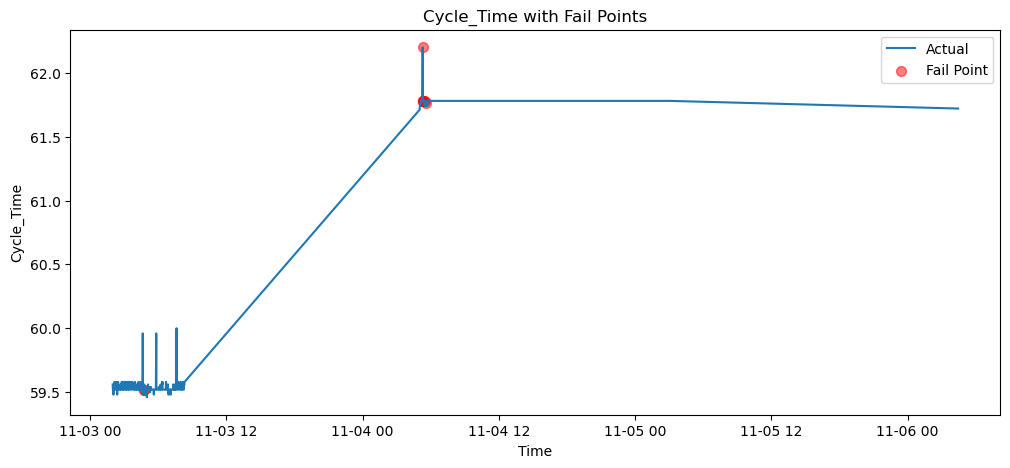

In [22]:
# ---------------------------------------------------------
# 12. 불량 발생 시점 같이 보기
# ---------------------------------------------------------
plt.figure(figsize=(12, 5))
plt.plot(test_df["TimeStamp"], y_test.values, label="Actual")
# plt.scatter(fail_df["TimeStamp"], fail_df[target_col], label="Fail Point", color="red")
# alpha=0.3을 주어 겹칠수록 진한 빨간색이 되도록 설정
plt.scatter(fail_df["TimeStamp"], fail_df[target_col],
            label="Fail Point", color="red", s=50, alpha=0.5)
plt.title("Cycle_Time with Fail Points")
plt.xlabel("Time")
plt.ylabel("Cycle_Time")
plt.legend()
plt.show()

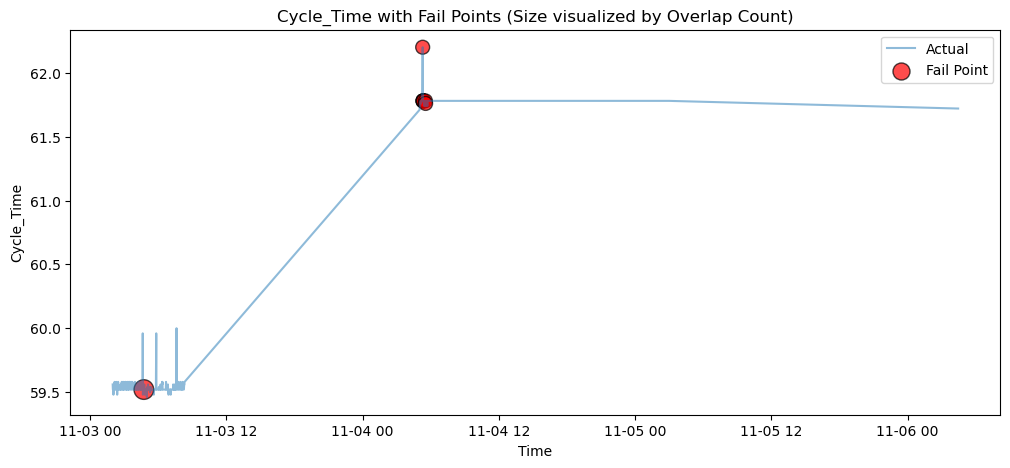

In [23]:
# ---------------------------------------------------------
# 중복 개수 계산 로직 추가
# ---------------------------------------------------------
# 시간과 값(target_col)이 완전히 같은 데이터를 그룹화하여 개수(count)를 셉니다.
overlap_counts = fail_df.groupby(["TimeStamp", target_col]).size().reset_index(name='count')

# ---------------------------------------------------------
# 12. 불량 발생 시점 같이 보기 (점 크기 적용)
# ---------------------------------------------------------
plt.figure(figsize=(12, 5))
plt.plot(test_df["TimeStamp"], y_test.values, label="Actual", alpha=0.5) # 선은 살짝 흐리게

# overlap_counts 데이터를 사용합니다.
# s (size) 옵션에 중복 개수('count')에 비례하는 값을 넣습니다.
# (기본 크기 20 + 개수당 30씩 증가, alpha도 살짝 줌)
plt.scatter(overlap_counts["TimeStamp"], overlap_counts[target_col],
            label="Fail Point",
            color="red",
            s=overlap_counts['count'] * 100, # <--- 중복 개수에 따라 크기 변경
            alpha=0.7,
            edgecolors='black') # 테두리를 그리면 겹침이 더 잘 보임

plt.title("Cycle_Time with Fail Points (Size visualized by Overlap Count)")
plt.xlabel("Time")
plt.ylabel("Cycle_Time")
plt.legend()
plt.show()

In [24]:
# end